# 02 - Study area and candidate stops

Purpose: define the Birmingham Knowledge Quarter / east Birmingham study area, validate the LSOA deprivation/population geography, and create candidate stop locations for later accessibility and optimisation notebooks.

## What this notebook does

- Checks raw and processed Stage 0 files.
- Builds processed LSOA geography if needed.
- Builds NaPTAN-derived Birmingham stops and study-area candidate stops if needed.
- Verifies IMD/population join quality.
- Plots deprivation and candidate stops together.
- Leaves R5 travel-time and accessibility maths for Notebook 3.

In [31]:
from pathlib import Path
import json
import os
import subprocess
import sys

import geopandas as gpd
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))
import matplotlib.pyplot as plt

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"

STUDY_AREA_WGS84_BBOX = {
    "min_lon": -1.935,
    "min_lat": 52.465,
    "max_lon": -1.820,
    "max_lat": 52.515,
}

STUDY_AREA_WGS84_BBOX

{'min_lon': -1.935, 'min_lat': 52.465, 'max_lon': -1.82, 'max_lat': 52.515}

### Output: study-area bounding box

This first-pass bounding box should capture B-KQ, Eastside, Nechells, Aston, and nearby central/east Birmingham neighbourhoods. Keep it fixed across Stage 0 unless we intentionally revise the study area.

## File status

Raw files are downloaded by `scripts/fetch_data.py`. Processed geography comes from `scripts/build_stage0_geography.py`. Processed stops come from `scripts/build_stage0_stops.py`.

In [32]:
raw_files = {
    "birmingham_lsoa_boundaries": DATA_RAW / "birmingham_lsoa_2021_boundaries.geojson",
    "imd_file7": DATA_RAW / "imd_2025_file_7_all_ranks_scores_deciles_population_denominators.csv",
    "ons_population": DATA_RAW / "ons_lsoa_population_broad_age_mid_2022_revised_to_mid_2024.xlsx",
    "naptan_atco_430": DATA_RAW / "naptan_atco_430_west_midlands.csv",
}

processed_files = {
    "all_birmingham_lsoa": DATA_PROCESSED / "lsoa_imd_population.geojson",
    "study_area_lsoa": DATA_PROCESSED / "study_area_lsoa_imd_population.geojson",
    "geography_metadata": DATA_PROCESSED / "stage0_geography_metadata.json",
    "birmingham_stops": DATA_PROCESSED / "naptan_birmingham_stops.geojson",
    "candidate_stops": DATA_PROCESSED / "candidate_stops.geojson",
    "stops_metadata": DATA_PROCESSED / "stage0_stops_metadata.json",
}

def file_status(paths: dict[str, Path]) -> pd.DataFrame:
    rows = []
    for key, path in paths.items():
        rows.append(
            {
                "key": key,
                "path": path.relative_to(ROOT).as_posix(),
                "exists": path.exists(),
                "size_mb": round(path.stat().st_size / 1_000_000, 3) if path.exists() else 0,
            }
        )
    return pd.DataFrame(rows)

pd.concat([file_status(raw_files), file_status(processed_files)], ignore_index=True)

,key,path,exists,size_mb
0,birmingham_lsoa_boundaries,data/raw/birmingham_lsoa_2021_boundaries.geojson,True,1.129
1,imd_file7,data/raw/imd_2025_file_7_all_ranks_scores_deci...,True,9.898
2,ons_population,data/raw/ons_lsoa_population_broad_age_mid_202...,True,13.063
3,naptan_atco_430,data/raw/naptan_atco_430_west_midlands.csv,True,3.787
4,all_birmingham_lsoa,data/processed/lsoa_imd_population.geojson,True,1.514
5,study_area_lsoa,data/processed/study_area_lsoa_imd_population....,True,0.380
6,geography_metadata,data/processed/stage0_geography_metadata.json,True,0.001
7,birmingham_stops,data/processed/naptan_birmingham_stops.geojson,True,3.854
8,candidate_stops,data/processed/candidate_stops.geojson,True,0.448
9,stops_metadata,data/processed/stage0_stops_metadata.json,True,0.001


### Output: file status table

Every row should be `True` before moving to Notebook 3. If a raw file is missing, run the relevant `scripts/fetch_data.py --datasets ...` command. If a processed file is missing, the next two cells will build it.

## Build processed geography if needed

The repeatable IMD/population/boundary join lives in a script so this notebook remains an audit trail rather than a hidden production pipeline.

In [33]:
required_geography = [
    processed_files["all_birmingham_lsoa"],
    processed_files["study_area_lsoa"],
    processed_files["geography_metadata"],
]

if not all(path.exists() for path in required_geography):
    subprocess.run(
        [sys.executable, str(ROOT / "scripts" / "build_stage0_geography.py")],
        check=True,
        cwd=ROOT,
    )

file_status({key: processed_files[key] for key in ["all_birmingham_lsoa", "study_area_lsoa", "geography_metadata"]})

,key,path,exists,size_mb
0,all_birmingham_lsoa,data/processed/lsoa_imd_population.geojson,True,1.514
1,study_area_lsoa,data/processed/study_area_lsoa_imd_population....,True,0.380
2,geography_metadata,data/processed/stage0_geography_metadata.json,True,0.001


### Output: processed geography status

All three rows should be `True`. If this fails, check that the Birmingham boundary, IMD 2025 File 7, and ONS population workbook are present in `data/raw`.

## Build processed stops if needed

NaPTAN area `430` provides West Midlands access nodes. The script filters active stops to Birmingham LSOAs, then aggregates study-area stop nodes by LSOA + mode + common name to form candidate stop locations.

In [34]:
required_stops = [
    processed_files["birmingham_stops"],
    processed_files["candidate_stops"],
    processed_files["stops_metadata"],
]

if not all(path.exists() for path in required_stops):
    subprocess.run(
        [sys.executable, str(ROOT / "scripts" / "build_stage0_stops.py")],
        check=True,
        cwd=ROOT,
    )

file_status({key: processed_files[key] for key in ["birmingham_stops", "candidate_stops", "stops_metadata"]})

,key,path,exists,size_mb
0,birmingham_stops,data/processed/naptan_birmingham_stops.geojson,True,3.854
1,candidate_stops,data/processed/candidate_stops.geojson,True,0.448
2,stops_metadata,data/processed/stage0_stops_metadata.json,True,0.001


### Output: processed stop status

All three rows should be `True`. These files are the bridge from raw transport access nodes to the optimiser's candidate stop set.

## Load processed layers

`lsoa` contains all Birmingham LSOAs. `study_area_lsoa` contains the Stage 0 bounding-box subset. `birmingham_stops` contains active NaPTAN stops inside Birmingham. `candidate_stops` contains aggregated candidate locations inside the study area.

In [35]:
lsoa = gpd.read_file(processed_files["all_birmingham_lsoa"])
study_area_lsoa = gpd.read_file(processed_files["study_area_lsoa"])
birmingham_stops = gpd.read_file(processed_files["birmingham_stops"])
candidate_stops = gpd.read_file(processed_files["candidate_stops"])
geography_metadata = json.loads(processed_files["geography_metadata"].read_text())
stops_metadata = json.loads(processed_files["stops_metadata"].read_text())

pd.DataFrame(
    [
        {
            "dataset": "All Birmingham LSOAs",
            "rows": len(lsoa),
            "crs": str(lsoa.crs),
            "population_mid_2024": int(lsoa["population_mid_2024"].sum()),
            "most_deprived_decile_population_mid_2024": int(lsoa.loc[lsoa["imd_decile"].eq(1), "population_mid_2024"].sum()),
        },
        {
            "dataset": "Study-area LSOAs",
            "rows": len(study_area_lsoa),
            "crs": str(study_area_lsoa.crs),
            "population_mid_2024": int(study_area_lsoa["population_mid_2024"].sum()),
            "most_deprived_decile_population_mid_2024": int(study_area_lsoa.loc[study_area_lsoa["imd_decile"].eq(1), "population_mid_2024"].sum()),
        },
        {
            "dataset": "Active Birmingham NaPTAN stops",
            "rows": len(birmingham_stops),
            "crs": str(birmingham_stops.crs),
            "population_mid_2024": None,
            "most_deprived_decile_population_mid_2024": None,
        },
        {
            "dataset": "Study-area candidate stops",
            "rows": len(candidate_stops),
            "crs": str(candidate_stops.crs),
            "population_mid_2024": None,
            "most_deprived_decile_population_mid_2024": None,
        },
    ]
)

,dataset,rows,crs,population_mid_2024,most_deprived_decile_population_mid_2024
0,All Birmingham LSOAs,659,EPSG:4326,1183618.0,527951.0
1,Study-area LSOAs,174,EPSG:4326,349787.0,250646.0
2,Active Birmingham NaPTAN stops,4582,EPSG:4326,NaN,NaN
3,Study-area candidate stops,828,EPSG:4326,NaN,NaN


### Output: loaded layer summary

This is the main readiness check for moving on. We need real LSOA geography and a non-empty candidate stop set before Notebook 3 can prototype catchments.

## Join quality checks

Confirm that every Birmingham LSOA polygon has IMD and population fields.

In [36]:
join_checks = pd.DataFrame(
    [
        {"check": "All Birmingham LSOAs have IMD decile", "missing_rows": int(lsoa["imd_decile"].isna().sum())},
        {"check": "All Birmingham LSOAs have mid-2024 population", "missing_rows": int(lsoa["population_mid_2024"].isna().sum())},
        {"check": "Study-area LSOAs have IMD decile", "missing_rows": int(study_area_lsoa["imd_decile"].isna().sum())},
        {"check": "Study-area LSOAs have mid-2024 population", "missing_rows": int(study_area_lsoa["population_mid_2024"].isna().sum())},
    ]
)

join_checks

,check,missing_rows
0,All Birmingham LSOAs have IMD decile,0
1,All Birmingham LSOAs have mid-2024 population,0
2,Study-area LSOAs have IMD decile,0
3,Study-area LSOAs have mid-2024 population,0


### Output: join quality table

Every `missing_rows` value should be zero. If not, the geography join is not safe to use for accessibility metrics.

## Deprivation distribution

This checks whether the bbox contains the deprived neighbourhoods the project claims to prioritise.

In [37]:
decile_summary = (
    study_area_lsoa.groupby("imd_decile", as_index=False)
    .agg(
        lsoa_count=("lsoa21cd", "count"),
        population_mid_2024=("population_mid_2024", "sum"),
    )
    .sort_values("imd_decile")
)

decile_summary

,imd_decile,lsoa_count,population_mid_2024
0,1,125,250646
1,2,17,32379
2,3,10,22774
3,4,5,8792
4,5,4,6315
5,6,4,13417
6,7,3,5358
7,8,1,1353
8,9,3,4560
9,10,2,4193


### Output: deprivation distribution by IMD decile

IMD decile 1 is the most deprived 10% of English LSOAs. The strong concentration of decile 1-3 LSOAs is exactly why an equity-first routing lens is appropriate here.

## Candidate-stop summary

Candidate stops are aggregated from active NaPTAN nodes inside the study area. The cost assumptions are placeholders for Milestone 1 optimisation, not business-case estimates.

In [38]:
candidate_summary = (
    candidate_stops.groupby("mode_hint", as_index=False)
    .agg(
        candidate_count=("candidate_id", "count"),
        source_stop_nodes=("source_stop_count", "sum"),
        interchange_candidates=("is_interchange", "sum"),
        min_cost_gbp=("cost_gbp", "min"),
        max_cost_gbp=("cost_gbp", "max"),
    )
    .sort_values("mode_hint")
)

candidate_summary

,mode_hint,candidate_count,source_stop_nodes,interchange_candidates,min_cost_gbp,max_cost_gbp
0,bus,794,1182,0,75000,75000
1,bus_coach_station,1,15,0,100000,100000
2,rail,14,27,14,150000,150000
3,tram_metro,19,21,19,150000,150000


### Output: candidate-stop summary

The important values are that the candidate set is non-empty and includes rail/Metro interchange candidates. The optimiser will later use `candidate_id`, `cost_gbp`, `is_interchange`, and geometry.

## Deprivation choropleth and candidate stops

This is the visual checkpoint before moving on to accessibility maths.

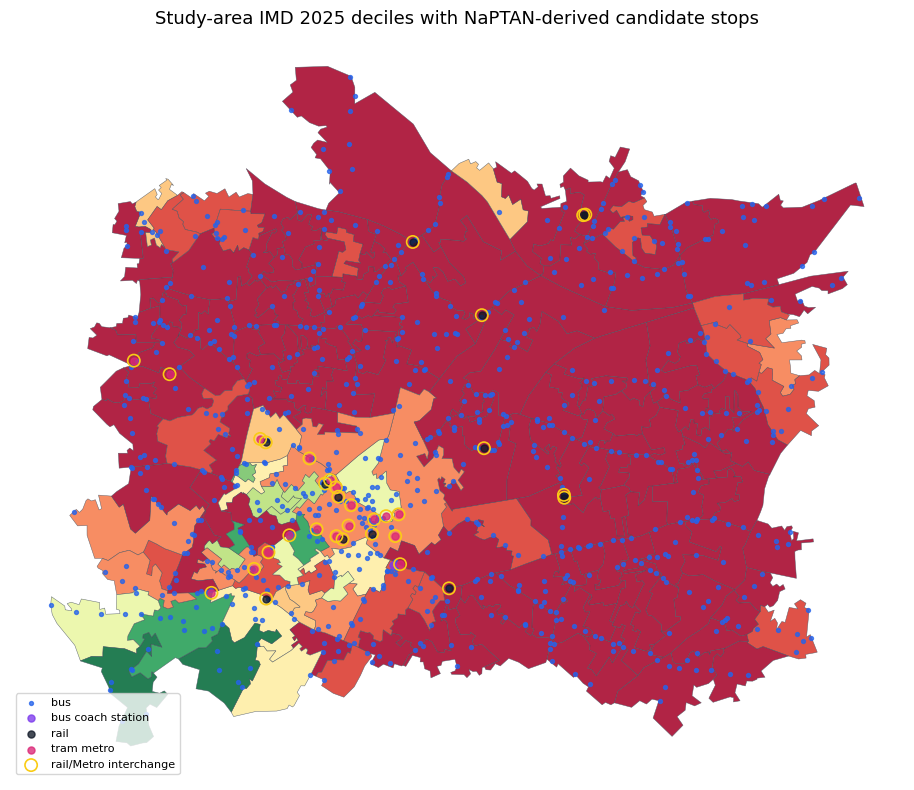

In [39]:
mode_colours = {
    "bus": "#2563eb",
    "bus_coach_station": "#7c3aed",
    "rail": "#111827",
    "tram_metro": "#db2777",
}

fig, ax = plt.subplots(figsize=(10, 8))

study_area_lsoa.plot(
    column="imd_decile",
    cmap="RdYlGn",
    categorical=True,
    legend=True,
    linewidth=0.35,
    edgecolor="#4b5563",
    alpha=0.86,
    ax=ax,
)

for mode_hint, colour in mode_colours.items():
    subset = candidate_stops.loc[candidate_stops["mode_hint"].eq(mode_hint)]
    if subset.empty:
        continue
    subset.plot(
        ax=ax,
        color=colour,
        markersize=8 if mode_hint == "bus" else 26,
        alpha=0.78,
        label=mode_hint.replace("_", " "),
    )

interchanges = candidate_stops.loc[candidate_stops["is_interchange"]]
interchanges.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#facc15",
    markersize=78,
    linewidth=1.2,
    label="rail/Metro interchange",
)

ax.set_title("Study-area IMD 2025 deciles with NaPTAN-derived candidate stops", fontsize=13)
ax.set_axis_off()
ax.legend(loc="lower left", frameon=True, fontsize=8)
plt.tight_layout()

### Output: choropleth with candidate stops

Redder polygons are more deprived. Blue points are bus candidates, black/pink points are rail/Metro candidates, and yellow outlines mark interchange candidates. This is now enough spatial structure for Notebook 3 to prototype catchment coverage.

## Candidate schema

This is the optimiser-facing shape produced by the Stage 0 stop pipeline.

In [40]:
candidate_columns = [
    "candidate_id",
    "name",
    "mode_hint",
    "lsoa21cd",
    "imd_decile",
    "cost_gbp",
    "is_interchange",
    "source_stop_count",
]

candidate_stops[candidate_columns].head(12)

,candidate_id,name,mode_hint,lsoa21cd,imd_decile,cost_gbp,is_interchange,source_stop_count
0,cand_c643950b0301,Abbotts Road,bus,E01009400,1,75000,False,1
1,cand_da0cf101c23f,Aberdeen Street,bus,E01009345,1,75000,False,2
2,cand_1052c559d370,Adderley Gardens,bus,E01034934,1,75000,False,1
3,cand_a4309ca3de7d,Adderley Gardens,bus,E01034933,1,75000,False,2
4,cand_5ba5536fcfb8,Adderley Park Station,bus,E01009192,1,75000,False,1
5,cand_ce66fc0f72ab,Adderley Park Station,bus,E01034935,1,75000,False,1
6,cand_532b66d15901,Adderley Street,bus,E01009200,1,75000,False,3
7,cand_bf7c433df810,Adderley Street,bus,E01034946,2,75000,False,1
8,cand_89275aa7dc13,Albert Road,bus,E01034920,1,75000,False,1
9,cand_cd80e6ed11d3,Albert Road,bus,E01034923,1,75000,False,1


### Output: candidate-stop sample

The stable `candidate_id` and explicit `cost_gbp`/`is_interchange` fields are the key columns for Notebook 4 and the Milestone 1 MILP.

## Findings log

- Geography checkpoint is real: Birmingham LSOA boundaries join to IMD 2025 and ONS mid-2024 population.
- Stop checkpoint is real: active NaPTAN ATCO 430 nodes are filtered to Birmingham and aggregated into study-area candidate stops.
- Current processed outputs: `lsoa_imd_population.geojson`, `study_area_lsoa_imd_population.geojson`, `naptan_birmingham_stops.geojson`, and `candidate_stops.geojson`.
- Candidate-stop costs are placeholder scenario costs for optimisation experiments; revisit before presenting value-for-money claims.
- Next notebook: prototype accessibility/catchment maths using these candidate stops and a synthetic travel-time matrix before R5.

## EDA interpretation

This section turns the processed layers into project insight. The goal is to make the notebook useful for decisions, not just prove that files load.

### Most deprived LSOAs in the study area

Lower IMD rank means more deprived. These are the neighbourhood units the equity objective should be most sensitive to.

In [41]:
top_deprived_lsoas = (
    study_area_lsoa[[
        "lsoa21cd",
        "boundary_lsoa21nm",
        "imd_rank",
        "imd_decile",
        "population_mid_2024",
        "centroid_lon",
        "centroid_lat",
    ]]
    .sort_values(["imd_rank", "population_mid_2024"], ascending=[True, False])
    .head(10)
)

top_deprived_lsoas

,lsoa21cd,boundary_lsoa21nm,imd_rank,imd_decile,population_mid_2024,centroid_lon,centroid_lat
95,E01009361,Birmingham 047E,117,1,2248,-1.939583,52.495583
35,E01009355,Birmingham 039E,135,1,1577,-1.921981,52.502630
7,E01008916,Birmingham 037E,136,1,1706,-1.882052,52.510313
38,E01009365,Birmingham 071D,157,1,2030,-1.876904,52.465225
91,E01009345,Birmingham 053D,202,1,2048,-1.937710,52.490713
73,E01009053,Birmingham 033B,227,1,1604,-1.889432,52.512743
97,E01009364,Birmingham 071C,310,1,1648,-1.882013,52.468368
3,E01008907,Birmingham 040B,329,1,1867,-1.916538,52.500197
42,E01009482,Birmingham 048C,334,1,1848,-1.855648,52.495695
98,E01009379,Birmingham 071E,345,1,2057,-1.867963,52.471164


### Output: top deprived LSOAs

This table gives a concrete geography for the equity claim. Later, when the optimiser selects stops, we can check whether these high-need LSOAs are among those brought within reach.

### Population concentration by deprivation decile

This calculates how much of the study-area population sits in the most deprived deciles. If the study area is genuinely equity-critical, deciles 1-3 should account for a large share.

In [42]:
decile_population_share = decile_summary.copy()
decile_population_share["population_share"] = (
    decile_population_share["population_mid_2024"]
    / decile_population_share["population_mid_2024"].sum()
)
decile_population_share["population_share_pct"] = (
    decile_population_share["population_share"] * 100
).round(1)

bottom_three_population = int(
    decile_population_share.loc[
        decile_population_share["imd_decile"].le(3), "population_mid_2024"
    ].sum()
)
bottom_three_share_pct = round(
    bottom_three_population / int(decile_population_share["population_mid_2024"].sum()) * 100,
    1,
)

decile_population_share, {
    "bottom_three_decile_population": bottom_three_population,
    "bottom_three_decile_share_pct": bottom_three_share_pct,
}

(   imd_decile  lsoa_count  population_mid_2024  population_share  \
 0           1         125               250646          0.716568   
 1           2          17                32379          0.092568   
 2           3          10                22774          0.065108   
 3           4           5                 8792          0.025135   
 4           5           4                 6315          0.018054   
 5           6           4                13417          0.038358   
 6           7           3                 5358          0.015318   
 7           8           1                 1353          0.003868   
 8           9           3                 4560          0.013037   
 9          10           2                 4193          0.011987   
 
    population_share_pct  
 0                  71.7  
 1                   9.3  
 2                   6.5  
 3                   2.5  
 4                   1.8  
 5                   3.8  
 6                   1.5  
 7                   0.

### Output: deprivation-weighted population concentration

This is the clearest EDA justification for an equity-first metric. A high bottom-three-decile share means the study area contains many residents the project is explicitly trying to prioritise.

### Candidate stops by deprivation context

This checks whether candidate stops are available in the LSOAs that matter most, rather than only around the already-connected city core.

In [43]:
candidate_by_decile = (
    candidate_stops.groupby("imd_decile", as_index=False)
    .agg(
        candidate_count=("candidate_id", "count"),
        interchange_candidates=("is_interchange", "sum"),
        source_stop_nodes=("source_stop_count", "sum"),
    )
    .sort_values("imd_decile")
)

candidate_by_decile

,imd_decile,candidate_count,interchange_candidates,source_stop_nodes
0,1,530,11,766
1,2,86,1,146
2,3,99,13,163
3,4,18,2,28
4,5,24,1,36
5,6,26,1,46
6,7,12,2,15
7,8,2,0,2
8,9,18,2,22
9,10,13,0,21


### Output: candidate stops by IMD decile

This table is an early feasibility check. If deprived deciles had very few candidate stops, the optimiser would have little room to improve equity without generating new stops.

### Candidate mode mix

This checks what kind of network the candidate layer represents: mostly local bus stops, with rail and Metro nodes acting as interchange anchors.

In [44]:
mode_mix = (
    candidate_stops.groupby("mode_hint", as_index=False)
    .agg(
        candidate_count=("candidate_id", "count"),
        source_stop_nodes=("source_stop_count", "sum"),
        interchange_candidates=("is_interchange", "sum"),
        median_cost_gbp=("cost_gbp", "median"),
    )
    .sort_values("candidate_count", ascending=False)
)
mode_mix["candidate_share_pct"] = (
    mode_mix["candidate_count"] / mode_mix["candidate_count"].sum() * 100
).round(1)

mode_mix

,mode_hint,candidate_count,source_stop_nodes,interchange_candidates,median_cost_gbp,candidate_share_pct
0,bus,794,1182,0,75000.0,95.9
3,tram_metro,19,21,19,150000.0,2.3
2,rail,14,27,14,150000.0,1.7
1,bus_coach_station,1,15,0,100000.0,0.1


### Output: candidate mode mix

A bus-heavy candidate set is expected for feeder-transit routing. The rail/Metro candidates are still important because Milestone 1 requires an interchange constraint.

### EDA findings

- The selected study area is strongly deprivation-weighted: most residents are in IMD decile 1, with a large majority in deciles 1-3.
- This supports using an equity-weighted accessibility objective rather than a purely population-maximising objective.
- The candidate layer is mostly bus stops, which fits the feeder-transit framing.
- Rail and Metro candidates exist inside the study area, so the mandatory interchange constraint is feasible.
- Candidate-stop costs are still placeholder scenario costs; they are suitable for optimiser prototyping but not final value-for-money claims.
- Notebook 3 can now prototype catchments using `study_area_lsoa` as origins and `candidate_stops` as candidate destinations.